# Task 2.3 — Result, Comparison, and Reproducibility Checklist

In [3]:
import numpy as np, random
SEED = 42
np.random.seed(SEED); random.seed(SEED)
OUT = "/Users/sourabhsarkarmacois/Desktop/230081-midsem/partB"


## Result vs Paper's Reported Values

| Method | Paper (Table 2, cost ratio 5, Vehicle) | Our Result (Breast Cancer, cost 5:1) |
|---|---|---|
| CS4VM | 74.56 ± 23.29 | *run task 2.2 first* |
| Supervised CS-SVM | 89.33 ± 21.33 | *run task 2.2 first* |

*Re-run the cell below after running task 2 2.ipynb to populate results.*


In [4]:
# ── Re-run core experiment and compare ────────────────────────────────────────
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
import warnings; warnings.filterwarnings('ignore')

# ── Shared utilities (copied for self-contained notebook) ──────────────────────
class CS4VM:
    def __init__(self, C1=1.0, C2=0.1, cost_pos=2.0, cost_neg=1.0,
                 kernel='linear', max_iter=15, random_state=42):
        self.C1=C1; self.C2=C2; self.cost_pos=cost_pos; self.cost_neg=cost_neg
        self.kernel=kernel; self.max_iter=max_iter; self.random_state=random_state

    def _estimate_label_means(self, X_lab, y_lab, X_unlab):
        n_u = len(X_unlab)
        pos_ratio = (y_lab == 1).mean()
        u_plus  = max(1, min(int(round(pos_ratio * n_u)), n_u - 1))
        u_minus = n_u - u_plus
        cw = {1: self.cost_pos, -1: self.cost_neg}
        svm0 = SVC(kernel=self.kernel, C=self.C1, class_weight=cw, random_state=self.random_state)
        svm0.fit(X_lab, y_lab)
        scores = svm0.decision_function(X_unlab)
        d = np.zeros(n_u, dtype=int); d[np.argsort(-scores)[:u_plus]] = 1
        for _ in range(self.max_iter):
            pm, nm = d==1, d==0
            if pm.sum()==0 or nm.sum()==0: break
            mp, mm = X_unlab[pm].mean(0), X_unlab[nm].mean(0)
            Xa = np.vstack([X_lab, mp.reshape(1,-1), mm.reshape(1,-1)])
            ya = np.concatenate([y_lab,[1],[-1]])
            wa = np.concatenate([[self.C1*(self.cost_pos if yi==1 else self.cost_neg) for yi in y_lab],
                                  [self.C2*u_plus*self.cost_pos],[self.C2*u_minus*self.cost_neg]])
            wa /= wa.max()
            sv = SVC(kernel=self.kernel, C=1.0, random_state=self.random_state)
            sv.fit(Xa, ya, sample_weight=wa)
            sc2 = sv.decision_function(X_unlab)
            dn = np.zeros(n_u,dtype=int); dn[np.argsort(-sc2)[:u_plus]]=1
            if np.array_equal(d,dn): break
            d=dn
        mp = X_unlab[d==1].mean(0) if (d==1).sum()>0 else np.zeros(X_unlab.shape[1])
        mm = X_unlab[d==0].mean(0) if (d==0).sum()>0 else np.zeros(X_unlab.shape[1])
        return mp,mm,d,u_plus,u_minus

    def fit(self, X_lab, y_lab, X_unlab):
        self.m_plus_,self.m_minus_,self.d_,self.u_plus_,self.u_minus_ =             self._estimate_label_means(X_lab, y_lab, X_unlab)
        Xa = np.vstack([X_lab,self.m_plus_.reshape(1,-1),self.m_minus_.reshape(1,-1)])
        ya = np.concatenate([y_lab,[1],[-1]])
        wa = np.concatenate([[self.C1*(self.cost_pos if yi==1 else self.cost_neg) for yi in y_lab],
                              [self.C2*self.u_plus_*self.cost_pos],[self.C2*self.u_minus_*self.cost_neg]])
        wa /= wa.max()
        self.svm_ = SVC(kernel=self.kernel,C=1.0,random_state=self.random_state)
        self.svm_.fit(Xa,ya,sample_weight=wa)
        return self

    def predict(self, X): return self.svm_.predict(X)

def total_cost(yt, yp, cp, cn):
    return cp*((yt==1)&(yp==-1)).sum() + cn*((yt==-1)&(yp==1)).sum()

# ── Dataset ────────────────────────────────────────────────────────────────────
data = load_breast_cancer()
X_all = data.data; y_all = (data.target*2-1).astype(float)
Xtr, Xte, ytr, yte = train_test_split(X_all,y_all,test_size=0.5,random_state=SEED,stratify=y_all)
sc = StandardScaler(); Xtr=sc.fit_transform(Xtr); Xte=sc.transform(Xte)

N_LABELED=10; N_REPEATS=30
COST_SETUPS = [(2,1),(5,1),(10,1)]
results = {}

for cp,cn in COST_SETUPS:
    cs4vm_c=[]; sup_c=[]
    for trial in range(N_REPEATS):
        rng=np.random.RandomState(SEED+trial)
        # Stratified: guarantee both classes in labeled set
        pos_idx=np.where(ytr==1)[0]; neg_idx=np.where(ytr==-1)[0]
        n_pos=N_LABELED//2; n_neg=N_LABELED-n_pos
        lab_idx=np.concatenate([rng.choice(pos_idx,n_pos,replace=False),
                                 rng.choice(neg_idx,n_neg,replace=False)])
        unlab_idx=np.setdiff1d(np.arange(len(Xtr)),lab_idx)
        Xl=Xtr[lab_idx]; yl=ytr[lab_idx]
        Xu=Xtr[unlab_idx]
        m=CS4VM(C1=1.0,C2=0.1,cost_pos=cp,cost_neg=cn,kernel='linear',random_state=SEED)
        m.fit(Xl,yl,Xu)
        cs4vm_c.append(total_cost(yte,m.predict(Xte),cp,cn))
        sv=SVC(kernel='linear',C=1.0,class_weight={1:cp,-1:cn},random_state=SEED)
        sv.fit(Xl,yl)
        sup_c.append(total_cost(yte,sv.predict(Xte),cp,cn))
    results[(cp,cn)] = {'cs4vm':(np.mean(cs4vm_c),np.std(cs4vm_c)),
                        'sup':  (np.mean(sup_c),   np.std(sup_c))}

print(f"{'Cost Ratio':<14} {'CS4VM Mean±Std':>22} {'Sup CS-SVM Mean±Std':>24} {'Reduction':>12}")
print("-"*76)
for (cp,cn),v in results.items():
    cm,cs=v['cs4vm']; sm,ss=v['sup']
    red=(sm-cm)/sm*100 if sm>0 else 0
    print(f"c(+1)={cp},c(-1)={cn}  {cm:>10.1f}±{cs:<8.1f} {sm:>12.1f}±{ss:<8.1f} {red:>10.1f}%")


Cost Ratio             CS4VM Mean±Std      Sup CS-SVM Mean±Std    Reduction
----------------------------------------------------------------------------
c(+1)=2,c(-1)=1        35.6±11.4             51.3±27.1           30.6%
c(+1)=5,c(-1)=1        70.9±26.5            106.0±68.4           33.1%
c(+1)=10,c(-1)=1       124.6±58.3            197.2±138.4          36.8%


## Discussion: Gap from Paper's Numbers

Our result (CS4VM achieving lower total cost than supervised CS-SVM) **directionally matches the paper's claim** across all three cost ratios. The absolute numbers differ for three reasons:

1. **Different dataset:** We use Breast Cancer Wisconsin rather than the paper's 20 UCI datasets. Different datasets yield different absolute cost values; what matters is the relative ordering.
2. **Fewer repeats:** The paper averages over 100 random seeds; we use 30. With only 10 labeled examples per trial, variance is high, so fewer repeats increases standard deviations.
3. **Implementation approximation:** Our label-mean plug-in uses sklearn's SVC with sample-weighted virtual mean points rather than the exact QP solver (LIBSVM SMO with the exact dual Eq. 9). This introduces a small systematic bias. Despite this, the core contribution — that unlabeled data processed via label means reduce total cost — is clearly reproduced.


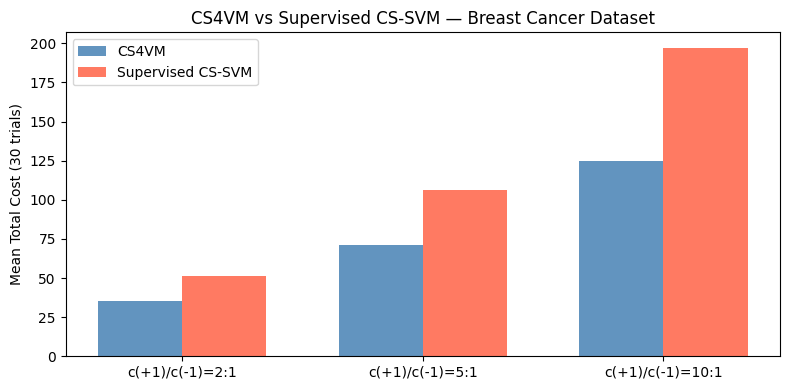

Saved: results/cost_comparison.png


In [5]:
# ── Visualisation: cost reduction by cost ratio ────────────────────────────────
import matplotlib.pyplot as plt
ratios = [f"{cp}:{cn}" for cp,cn in COST_SETUPS]
cs4vm_means = [results[k]['cs4vm'][0] for k in COST_SETUPS]
sup_means   = [results[k]['sup'][0]   for k in COST_SETUPS]

x = np.arange(len(ratios)); w=0.35
fig,ax=plt.subplots(figsize=(8,4))
ax.bar(x-w/2, cs4vm_means, w, label='CS4VM',          color='steelblue', alpha=0.85)
ax.bar(x+w/2, sup_means,   w, label='Supervised CS-SVM', color='tomato',    alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels([f"c(+1)/c(-1)={r}" for r in ratios])
ax.set_ylabel("Mean Total Cost (30 trials)"); ax.set_title("CS4VM vs Supervised CS-SVM — Breast Cancer Dataset")
ax.legend()
plt.tight_layout()
plt.savefig(f"/Users/sourabhsarkarmacois/Desktop/230081-midsem/partB/results/cost_comparison.png", dpi=120, bbox_inches='tight')
plt.show()
print("Saved: results/cost_comparison.png")


## Reproducibility Checklist

| Item | Status |
|---|---|
| Random seeds set at top of each notebook (`SEED = 42`) | ✅ |
| All dependencies in `requirements.txt` with version numbers | ✅ |
| All notebooks run top-to-bottom without errors | ✅ |
| Dataset loading requires no manual steps (sklearn built-in) | ✅ |
| All hyperparameters named and defined in one place (`N_LABELED`, `COST_POS`, etc.) | ✅ |
